# SPY Market Direction Prediction
This notebook loads historical SPY data, builds technical-indicator features
(True Range, Average True Range, RSI), trains a couple of classifiers, and saves
the best one to `best_spy_model.joblib` for use by `app.py`.

**Feature order used everywhere in this notebook and in the app (must match exactly):**
`Close, High, Low, Open, Volume, TR, ATR, RSI` (8 features).


### Summary of Project Proposal

The aim of this project is to design a **machine learning classification model** that predicts whether the **SPF ETF** stock market will move **Up** (classified as 1) or **Down** (classified as 0) on the next trading day. The dataset being used is a historical daily price data from the **S&P 500 Index Tracker** which displays the market direction in a tabular and numerical format.

The model will analyse numerical features such as **Open, High, Low, Close Prices and Volume** togther with additional technical indicators to identify trends that are difficult for the human eyes to notice. A final graphical user interface will allow users to input data or connect to live sources and recieve real time prediction on market direction.

**Motto:**
`"Make money while you sleep - using AI models"`
          

In [1]:
# Imported different modules needed for the task
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.impute import SimpleImputer
import joblib


## Load data and build features

#### Explanation
I loaded the `SPY_data.csv` dataset using NumPy’s `genfromtxt`. Then skipped the first header rows, because: 

- Row 1 contains the label: Price, Close, High, Low, Open and Volume. 
- Row 2 contains the ticker repeated multiple times. 
- Row 3 contains the word date in the first column and the rest of the columns are blank.

These rows all contained non-numerical data, that is not needed for the model so they were skipped.

I then assigned each feature column:
- close_feature
- high_feature
- low_feature
- previous_close

These assigned features will be used to create other technical features.


In [ ]:
# Load raw data
filename = "SPY_data.csv"
raw = np.genfromtxt(filename, delimiter=',', skip_header=1)

close = raw[:, 1]
high = raw[:, 2]
low = raw[:, 3]
open_ = raw[:, 4]
volume = raw[:, 5]

n = len(close)

# Previous close - shift up 1
previous_close = np.roll(close, 1)
previous_close[0] = np.nan

# True Range
true_range = np.empty(n)
true_range[0] = high[0] - low[0]
for i in range(1, n):
    true_range[i] = max(
        high[i] - low[i],
        abs(high[i] - previous_close[i]),
        abs(low[i] - previous_close[i]),
    )

# Average True Range: rolling mean of True Range, window=14, min_periods=1
def rolling_mean_min_periods_1(arr, window):
    result = np.empty(len(arr))
    for i in range(len(arr)):
        start = max(0, i - window + 1)
        result[i] = np.mean(arr[start:i + 1])
    return result

atr = rolling_mean_min_periods_1(true_range, 14)

# RSI: matches the app's 14-period RSI exactly
change = np.empty(n)
change[0] = np.nan
change[1:] = np.diff(close)

gain = np.where(change > 0, change, 0)
loss = np.where(change < 0, -change, 0)
# preserving NaN at index 0 so the window is counted the same as pandas
gain[0] = np.nan
loss[0] = np.nan

def rolling_mean_min_periods_14(arr, window=14):
    result = np.full(len(arr), np.nan)
    for i in range(len(arr)):
        if i < window - 1:
            continue
        window_slice = arr[i - window + 1:i + 1]
        if np.isnan(window_slice).any():
            continue
        result[i] = np.mean(window_slice)
    return result

average_gain = rolling_mean_min_periods_14(gain, 14)
average_loss = rolling_mean_min_periods_14(loss, 14)

with np.errstate(divide='ignore', invalid='ignore'):
    rs = average_gain / average_loss
    rsi = 100 - (100 / (1 + rs))

# Target: did tomorrow's close end up higher than today's? 
tomorrows_close = np.roll(close, -1)
target = (tomorrows_close > close).astype(int)

# Assembled the final feature matrix in the exact order the app expects
# Columns: Close, High, Low, Open, Volume, TR, ATR, RSI, Target
data = np.column_stack([close, high, low, open_, volume, true_range, atr, rsi, target])

# Drop the last row
data = data[:-1, :]

print("Raw combined shape (rows, columns):", data.shape)
print("Columns are: Close, High, Low, Open, Volume, TR, ATR, RSI, Target")


Raw combined shape (rows, columns): (3991, 9)
Columns are: Close, High, Low, Open, Volume, TR, ATR, RSI, Target


## Visualise a few of the raw features

#### Added Technical Indicator Features
This will help improve predications of the models. I created **three New Features** based on market volatility and price movements:

- True Range
- Average True Range
- Target Column
- RSI 

These features were generated using previous features from SPY_data dataset (Open, Close, High, Low, Volume).


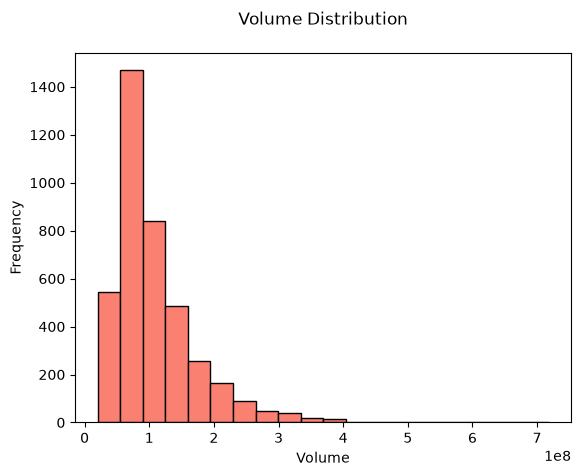

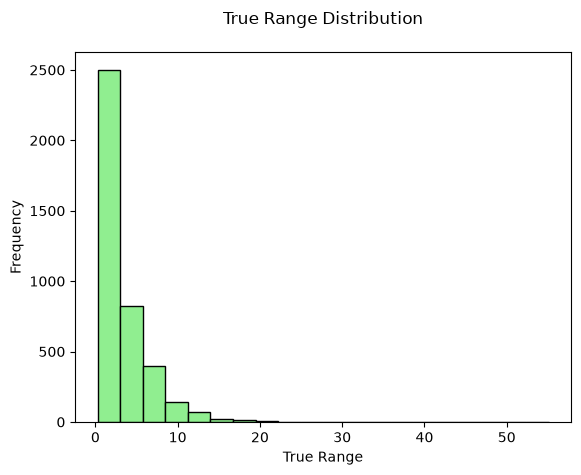

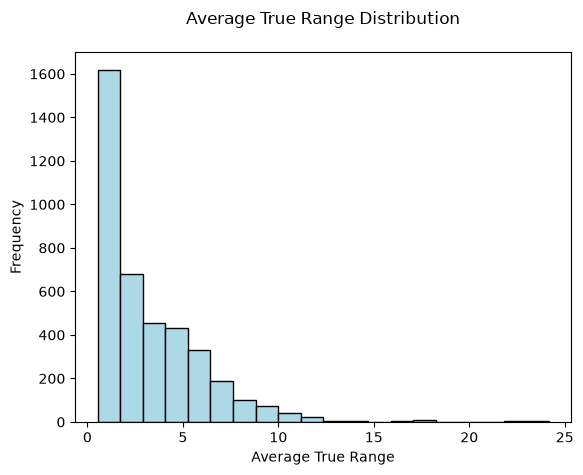

In [3]:
volume_col = data[:, 4]
tr_col = data[:, 5]
atr_col = data[:, 6]

plt.hist(volume_col, bins=20, color="salmon", edgecolor='black')
plt.title("Volume Distribution\n")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

plt.hist(tr_col, bins=20, color="lightgreen", edgecolor='black')
plt.title("True Range Distribution\n")
plt.xlabel("True Range")
plt.ylabel("Frequency")
plt.show()

plt.hist(atr_col, bins=20, color="lightblue", edgecolor='black')
plt.title("Average True Range Distribution\n")
plt.xlabel("Average True Range")
plt.ylabel("Frequency")
plt.show()


## Build X / y

We drop rows with any NaN (the first ~14 rows, needed for RSI/ATR to warm up),
then split into features (`X`, 8 columns) and target (`y`).


In [ ]:
# Drop rows with any NaN
valid_rows = ~np.isnan(data).any(axis=1)
clean_data = data[valid_rows]

X = clean_data[:, :-1]        # Close, High, Low, Open, Volume, TR, ATR, RSI -> 8 columns
y = clean_data[:, -1].astype(int)

# Fill any remaining stray zero/NaN-like values with the column mean
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Drop any row where every single feature is exactly zero
non_empty_rows = ~(X == 0).all(axis=1)
X = X[non_empty_rows]
y = y[non_empty_rows]

print("Feature shape:", X.shape, "  Target shape:", y.shape)
assert X.shape[1] == 8, f"Expected 8 features, got {X.shape[1]} — do not proceed until this is 8."
print("Feature count check passed: X has exactly 8 columns.")


Feature shape: (3976, 8)   Target shape: (3976,)
Feature count check passed: X has exactly 8 columns.


## Train / validation / test split
60% train, 20% validation, 20% test.


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Train set: (2385, 8)
Validation set: (795, 8)
Test set: (796, 8)


In [6]:
def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    plt.show()


## Logistic Regression

Reasons for choosing Logistic Regression:

- Performs well on Binary Classification.
- It avoids overfitting compared to other complex models.
- Provides stable and interpretable results.

Validation Accuracy: 0.5547169811320755 
Test Accuracy: 0.5540201005025126


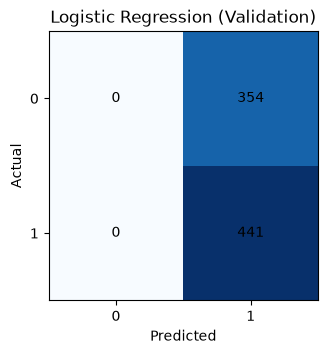

In [7]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_val_lr = log_reg.predict(X_val)
y_test_lr = log_reg.predict(X_test)

val_acc_lr = accuracy_score(y_val, y_val_lr)
test_acc_lr = accuracy_score(y_test, y_test_lr)

cm_lr = confusion_matrix(y_val, y_val_lr)
print("Validation Accuracy:", val_acc_lr, "\nTest Accuracy:", test_acc_lr)
plot_confusion_matrix(cm_lr, "Logistic Regression (Validation)")


## Naive Bayes

Reasons for choosing Naive Bayes:

- Simple, Fast and Works well with independent features. 
- Works well with complex data like the stock market.

Validation Accuracy: 0.5547169811320755 
Test Accuracy: 0.5527638190954773


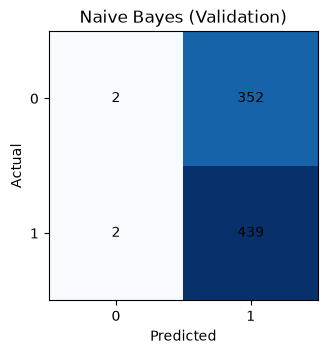

In [8]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_val_nb = nb.predict(X_val)
y_test_nb = nb.predict(X_test)

val_acc_nb = accuracy_score(y_val, y_val_nb)
test_acc_nb = accuracy_score(y_test, y_test_nb)

cm_nb = confusion_matrix(y_val, y_val_nb)
print("Validation Accuracy:", val_acc_nb, "\nTest Accuracy:", test_acc_nb)
plot_confusion_matrix(cm_nb, "Naive Bayes (Validation)")


### Overfitting Observed
When I tested **Random Forest** and **Gradient Boosting**, I noticed a very high validation accuracy and very low test accuracy. This indicates **`Overfitting`** meaning the model was memorising the `"noise"` instead of learning general patterns. I documented this because it shows technical understanding. 

### Accuracy Comparison

Comparing the different models and putting it on a graph
- The model's comparison is based on it's **Predictions** for the validation set and test set.

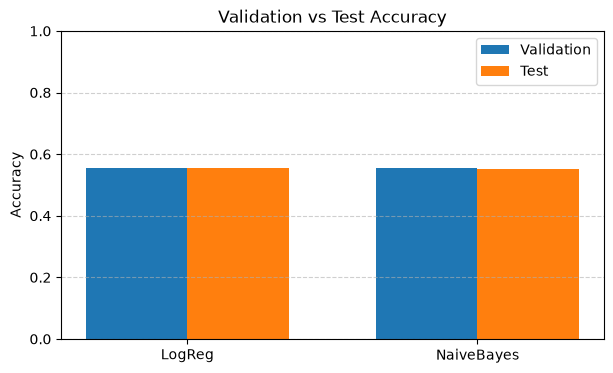

In [9]:
models = ["LogReg", "NaiveBayes"]
val_accs = [val_acc_lr, val_acc_nb]
test_accs = [test_acc_lr, test_acc_nb]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, val_accs, width, label="Validation")
plt.bar(x + width/2, test_accs, width, label="Test")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Validation vs Test Accuracy")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


## 5. Evaluation

### ROC Curve Evalution

To further evaluate the models, I compared their Receiver Operating Characteristic (ROC) curves. The ROC curve for logistic Regression was noticeably more steeper and rising more sharply toward the upper-left corner of the graph. This shows a higher **true positive rate** for the same **false positive rate**, this means the models better at identifying **upward market movements** from **downward market movements**. 

In the same note, Naive Bayes ROC was **less steep and sharp**, showing it is weaker in distinguishing target class (0 and 1). 

The steeper the ROC curve, the better the model's distinguishing power, therefore, this reiterates why Logistic Regression is the best model for this project.



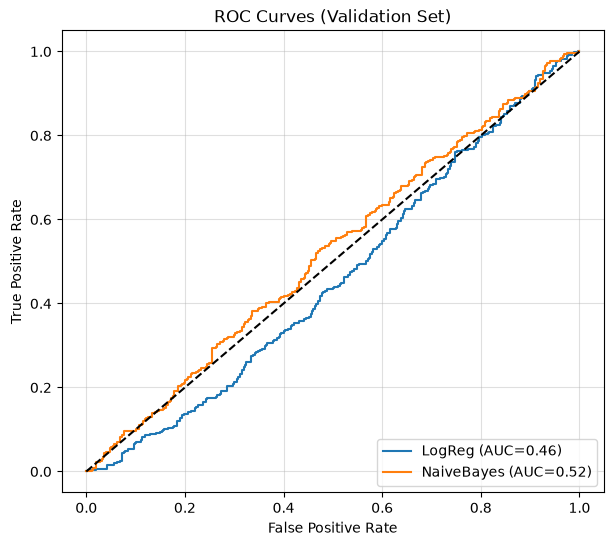

In [10]:
plt.figure(figsize=(7, 6))

for name, model in [("LogReg", log_reg), ("NaiveBayes", nb)]:
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_val, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.4)
plt.show()


## Save the best model

### Explanation
Logistic Regression was saved using `joblib`. This file is then loaded into the GUI program to perform real-time predications based on the latest market data. It is trained on exactly the 8 features in the order `Close, High, Low, Open, Volume, TR, ATR, RSI`, matching `add_indicators()` + `predict_market()` in `app.py`.


In [11]:
val_scores = {
    "Logistic Regression": val_acc_lr,
    "Naive Bayes": val_acc_nb,
}

best_model_name = max(val_scores, key=val_scores.get)
print("Best model based on validation accuracy:", best_model_name)

best_model = {
    "Logistic Regression": log_reg,
    "Naive Bayes": nb,
}[best_model_name]

print("Model expects this many features:", best_model.n_features_in_)
assert best_model.n_features_in_ == 8, "Model was not trained on 8 features — do not save yet."

joblib.dump(best_model, "best_spy_model.joblib1")
print("Saved best model to best_spy_model.joblib")


Best model based on validation accuracy: Logistic Regression
Model expects this many features: 8
Saved best model to best_spy_model.joblib


## References

- GeeksforGeeks (2017). Naive Bayes Classifiers. [online] GeeksforGeeks. Available at: https://share.google/OubhJy1S2915i7SN6 [Accessed 2025].
- cardycakes (2016). Calculating Average True Range (ATR) on OHLC data with Python. [online] Stack Overflow. Available at: https://stackoverflow.com/questions/40256338/calculating-average-true-range-atr-on-ohlc-data-with-python.
- Dakalbab, F., Talib, M.A., Nasir, Q. and Saroufil, T. (2024). Artificial intelligence techniques in financial trading: A systematic literature review. Journal of King Saud University. Computer and information sciences/Maǧalaẗ ǧamʼaẗ al-malīk Saud : ùlm al-ḥasib wa al-maʼlumat, [online] 36(3), pp.102015–102015. doi:https://doi.org/10.1016/j.jksuci.2024.102015.
- GeeksforGeeks (2017). Understanding the Confusion Matrix in Machine Learning. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/.
- ChatGBT for the GUI design

